# Performance

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
import pytz

## Data

In [7]:

performance_figures_out = '../../generated/figures/performance'
activity_csv_path = '../../generated/database/activity.csv'
coverage_csv_path = '../../generated/database/coverage.csv'

if not os.path.exists(activity_csv_path):
    raise FileNotFoundError(f"Le fichier {activity_csv_path} n'existe pas. Exécutez le notebook 'notebooks/arrange data/Database data.ipynb' pour le générer.")


df = pd.read_csv(activity_csv_path)

df

,user,achievement,game_mode,timestamp
0,70e85b5e-92d4-498a-9079-ba881f5b3b82,Add1TestAchievement,TEAM,2026-04-16 11:20:58.636937+02:00
1,960ad9f8-2b83-4526-9cfb-1a59cec049a6,Add1TestAchievement,SOLO,2026-04-16 11:21:48.854515+02:00
2,0d271530-be17-4538-bf04-dde3c6069b5f,Add1TestAchievement,SOLO,2026-04-16 11:21:54.247825+02:00
3,fb270a09-6a45-4eae-8f9a-3c808faec3ee,Add1TestAchievement,TEAM,2026-04-16 11:22:15.837729+02:00
4,c27240eb-52c0-4436-aa0f-e7f97a94a725,Add1TestAchievement,TEAM,2026-04-16 11:23:04.193050+02:00
...,...,...,...,...
68,0947a22a-ec40-4f49-867b-330a623a1a35,Kill75MutantsAchievement,TEAM,2026-04-16 12:27:27.874382+02:00
69,0947a22a-ec40-4f49-867b-330a623a1a35,CleanDragonAchievement,TEAM,2026-04-16 12:27:27.988965+02:00
70,70e85b5e-92d4-498a-9079-ba881f5b3b82,CleanDragonAchievement,TEAM,2026-04-16 12:27:28.031038+02:00
71,11555248-3f01-4d1c-9a71-ef7caf9150fa,Add10TestsAchievement,SOLO,2026-04-16 12:30:15.352811+02:00


## Achievements overview

In [3]:
counts = df["achievement"].value_counts()
counts

achievement
Add1TestAchievement         12
Add10TestsAchievement       10
Cover10LinesAchievement      9
Kill1MutantAchievement       7
Kill5MutantsAchievement      7
Kill10MutantsAchievement     7
Cover33LinesAchievement      5
Add20TestsAchievement        5
Kill25MutantsAchievement     5
CleanDragonAchievement       3
Kill66MutantsAchievement     2
Kill75MutantsAchievement     1
Name: count, dtype: int64

## Runs type

In [4]:
run_data = df.groupby(['game_mode', 'achievement']).size().reset_index(name='count')
run_data


,game_mode,achievement,count
0,SOLO,Add10TestsAchievement,7
1,SOLO,Add1TestAchievement,7
2,SOLO,Add20TestsAchievement,4
3,SOLO,Cover10LinesAchievement,6
4,SOLO,Cover33LinesAchievement,4
5,SOLO,Kill10MutantsAchievement,3
6,SOLO,Kill1MutantAchievement,3
7,SOLO,Kill25MutantsAchievement,2
8,SOLO,Kill5MutantsAchievement,3
9,SOLO,Kill66MutantsAchievement,1


# Nombre de tests par minute

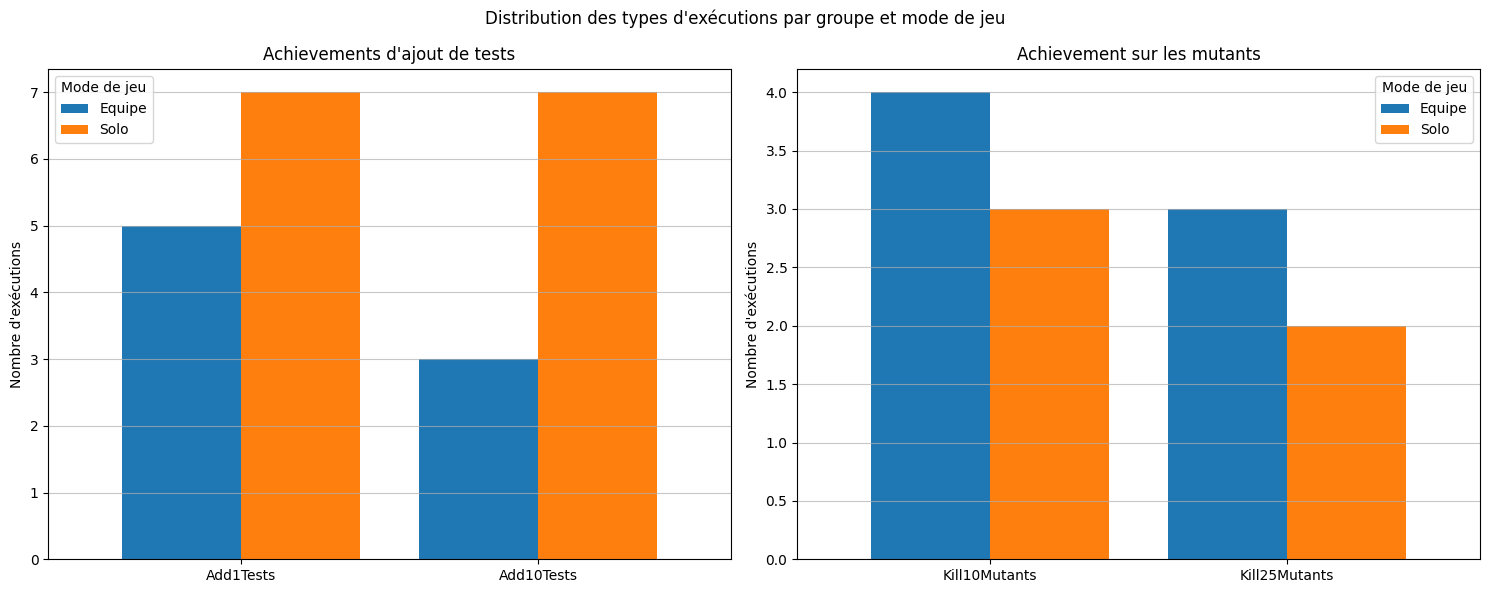

In [5]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

# Créer une figure plus compacte et lisible 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Add1 and 10 Tests Achievements 
team_achievements = run_data[(run_data['game_mode'] == 'TEAM')]
solo_achievements = run_data[(run_data['game_mode'] == 'SOLO')]

data = pd.DataFrame({
    'Equipe': [
        team_achievements[team_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0],
        team_achievements[team_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]
    ],
    'Solo': [
        solo_achievements[solo_achievements['achievement'] == 'Add1TestAchievement']['count'].values[0],
        solo_achievements[solo_achievements['achievement'] == 'Add10TestsAchievement']['count'].values[0]
    ]
}, index=['Add1Tests', 'Add10Tests'])

data.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title("Achievements d'ajout de tests")
ax1.set_ylabel("Nombre d'exécutions")
ax1.legend(title="Mode de jeu")
ax1.grid(True, axis='y', alpha=0.7)
ax1.tick_params(axis='x', rotation=0)

# Groupe B

solo_10mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
team_10mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill10MutantsAchievement']['count'].values[0]
solo_25mutants_achievement = \
    solo_achievements[solo_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]
team_25mutants_achievement = \
    team_achievements[team_achievements['achievement'] == 'Kill25MutantsAchievement']['count'].values[0]

data2 = pd.DataFrame({
    'Equipe': [team_10mutants_achievement, team_25mutants_achievement],
    'Solo': [solo_10mutants_achievement, solo_25mutants_achievement]
}, index=['Kill10Mutants', 'Kill25Mutants'])

data2.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title("Achievement sur les mutants")
ax2.set_ylabel("Nombre d'exécutions")
ax2.legend(title="Mode de jeu")
ax2.grid(True, axis='y', alpha=0.7)
ax2.tick_params(axis='x', rotation=0)

plt.suptitle("Distribution des types d'exécutions par groupe et mode de jeu")
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/runs_type_by_group_and_game_mode.pdf')
plt.show()

# Nombre de tests cumulé par minute

<Figure size 640x480 with 0 Axes>

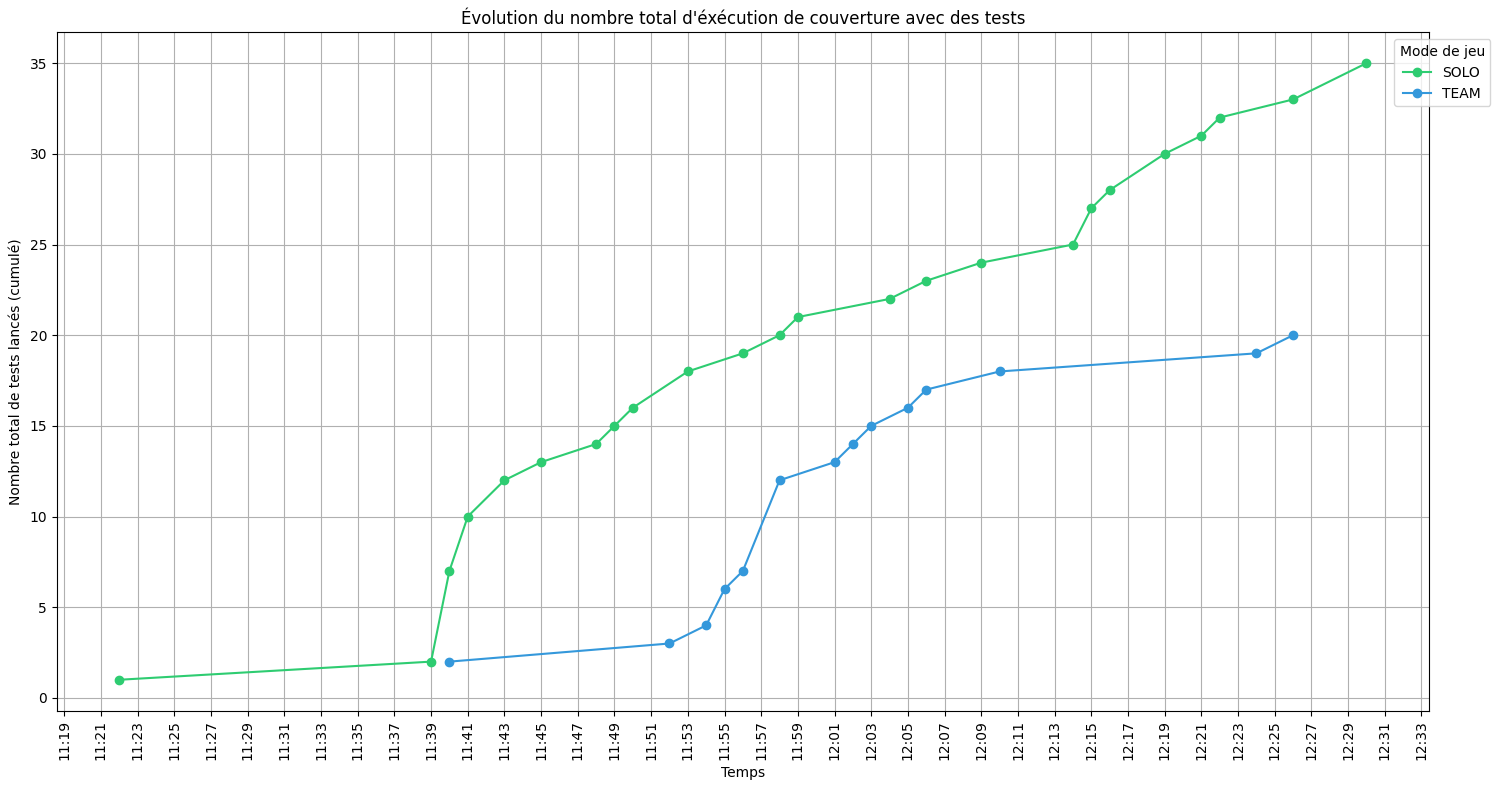

In [ ]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

df_coverage = pd.read_csv(coverage_csv_path)
df_coverage['created_at'] = pd.to_datetime(df_coverage['created_at'])
df_coverage['minute'] = df_coverage['created_at'].dt.floor('min')

team_coverage = df_coverage[df_coverage['game_mode'] == 'TEAM']
solo_coverage = df_coverage[df_coverage['game_mode'] == 'SOLO']

team_coverage['created_at'] = pd.to_datetime(team_coverage['created_at'])
solo_coverage['created_at'] = pd.to_datetime(solo_coverage['created_at'])

team_coverage['minute'] = team_coverage['created_at'].dt.floor('min')
solo_coverage['minute'] = solo_coverage['created_at'].dt.floor('min')

total_tests_per_minute = df_coverage.groupby(['minute', 'game_mode']).size().reset_index(name='count')
total_tests_per_minute = total_tests_per_minute.sort_values('minute')

plt.clf()  # Clear the current figure
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors for different groups and modes
colors = {
    'SOLO': '#2ecc71',  # Vert émeraude
    'TEAM': '#3498db',  # Bleu clair
}

# Plot cumulative data first
for mode in ['SOLO', 'TEAM']:
    data = total_tests_per_minute[(total_tests_per_minute['game_mode'] == mode)]

    data = data.sort_values('minute')
    data['cumulative_count'] = data['count'].cumsum()

    line_color = colors[(mode)]
    plt.plot(data['minute'], data['cumulative_count'], label=f'{mode}', color=line_color, marker='o')


plt.title('Évolution du nombre total d\'éxécution de couverture avec des tests')
plt.xlabel('Temps')
plt.ylabel('Nombre total de tests éxécutés (cumulé)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone('Europe/Brussels')))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.xticks(rotation=90)

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Mode de jeu', bbox_to_anchor=(1.05, 1))

plt.grid(True)
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/created_tests_count_cumsum.pdf')
plt.show()


<Figure size 1000x600 with 0 Axes>

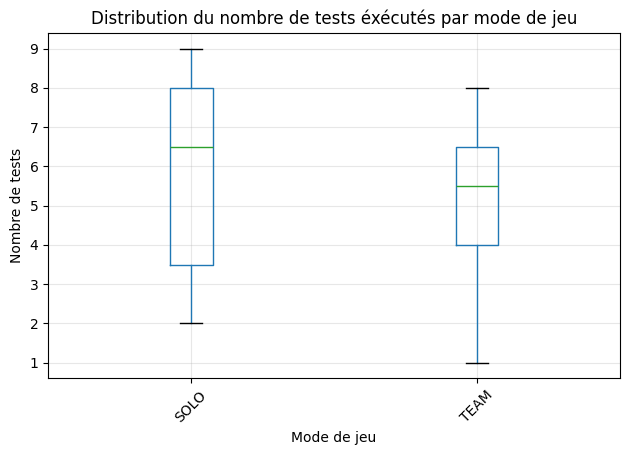

In [22]:
if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

# Création de la colonne count dans df_all_tests 
df_all_tests = df_coverage.groupby(['user', 'game_mode']).size().reset_index(
    name='count')

plt.figure(figsize=(10, 6))

# Create boxplot with groups split by game mode
boxplot = df_all_tests.boxplot(column='count', by=['game_mode'])

ax = plt.gca()
labels = [label.get_text().strip("(),'") for label in ax.get_xticklabels()]
ax.set_xticklabels(labels)

plt.title('Distribution du nombre de tests éxécutés par mode de jeu')
plt.suptitle('')  # Remove automatic suptitle
plt.xlabel('Mode de jeu')
plt.ylabel('Nombre de tests')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<Figure size 640x480 with 0 Axes>

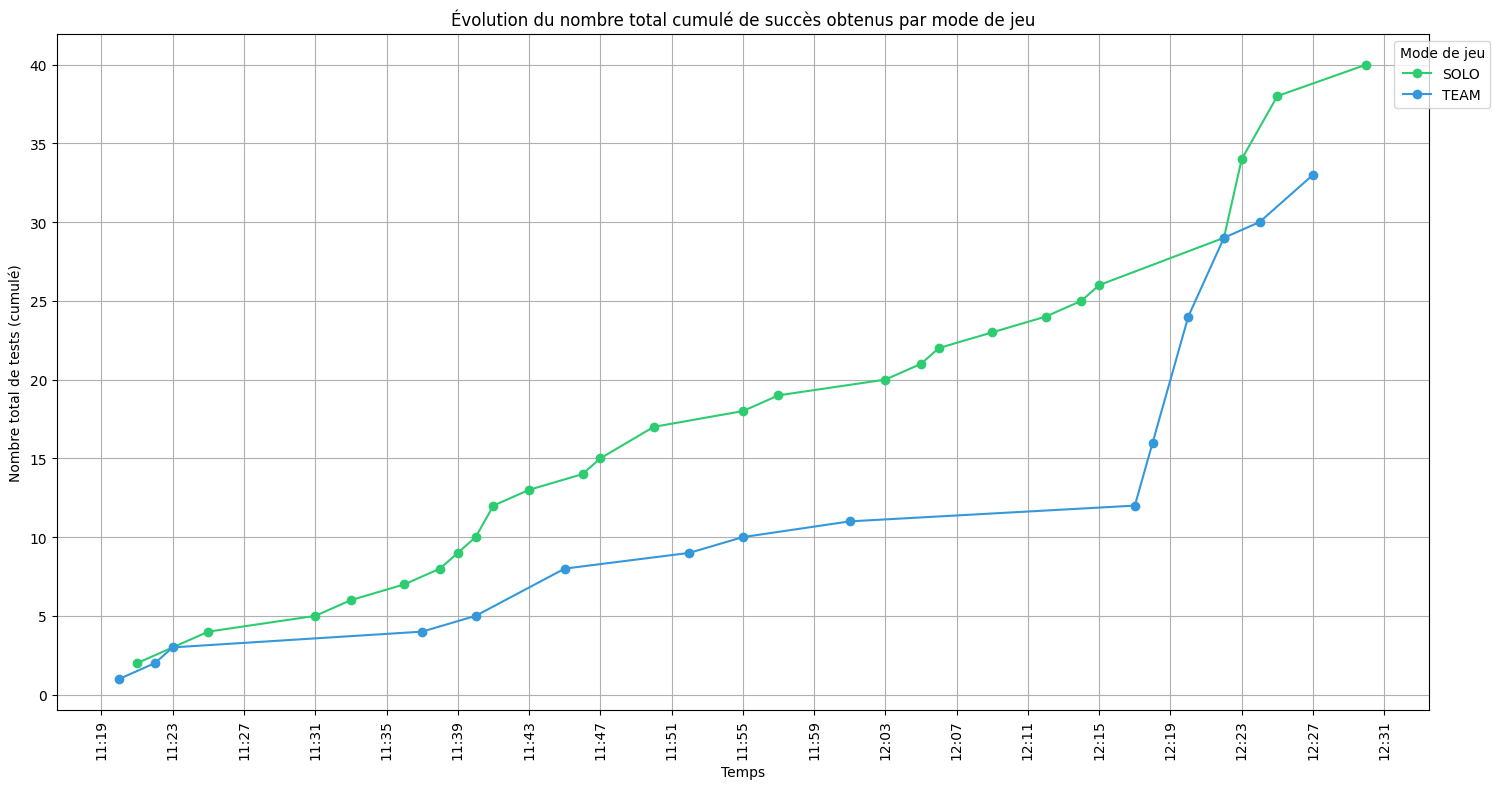

In [24]:
import pandas as pd
df_activity = pd.read_csv('../../generated/database/activity-brut.csv', sep = ',')
df_activity['timestamp'] = pd.to_datetime(df_activity['timestamp'], utc=False)

if not os.path.exists(performance_figures_out):
    os.makedirs(performance_figures_out)

df_all_tests = df_activity.copy()
df_all_tests['minute'] = df_all_tests['timestamp'].dt.floor('min')

total_tests_per_minute = df_all_tests.groupby(['minute', 'game_mode']).size().reset_index(name='count')
total_tests_per_minute = total_tests_per_minute.sort_values('minute')

plt.clf()  # Clear the current figure
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors for different groups and modes
colors = {
    'SOLO': '#2ecc71',  # Vert émeraude
    'TEAM': '#3498db',  # Bleu clair
}

# Plot cumulative data first
for mode in ['SOLO', 'TEAM']:
    data = total_tests_per_minute[(total_tests_per_minute['game_mode'] == mode)]

    data = data.sort_values('minute')
    data['cumulative_count'] = data['count'].cumsum()

    line_color = colors[( mode)]
    plt.plot(data['minute'], data['cumulative_count'],
                label=f'{mode}',
                color=line_color,
                marker='o')


plt.title('Évolution du nombre total cumulé de succès obtenus par mode de jeu')
plt.xlabel('Temps')
plt.ylabel('Nombre total de tests (cumulé)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone('Europe/Brussels')))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
plt.xticks(rotation=90)

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(),
           title='Mode de jeu',
           bbox_to_anchor=(1.05, 1))

plt.grid(True)
plt.tight_layout()
plt.savefig(f'{performance_figures_out}/actions_count_full_cumsum.pdf')
plt.show()
